# Graded Response Model — WPI (Single Scale)

Fits a single-dimensional GRM to all 116 WPI items. With binary responses (K=2), this is equivalent to a 2PL IRT model.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data

In [2]:
from bayesianquilts.data.wpi import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset shape: {df.shape}")
print(f"Number of people: {num_people}")
print(f"Number of items: {len(item_keys)}")
print(f"Response cardinality: {response_cardinality} (binary 0-1)")
df.head()

Dataset shape: (6019, 117)
Number of people: 6019
Number of items: 116
Response cardinality: 2 (binary 0-1)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,…,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,Q97,Q98,Q99,Q100,Q101,Q102,Q103,Q104,Q105,Q106,Q107,Q108,Q109,Q110,Q111,Q112,Q113,Q114,Q115,Q116
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1,1,0,0,0,1,1,0,1,0,1,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,0,0,…,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,1,1,0
1,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,-1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,0,1,1,0,1,0,0,1,1,1,1,0,1,1,-1,1,1,1,1,1,1,0,1,1,1,1,1,1,0,0,0,0
2,0,0,1,1,0,1,0,0,0,0,1,0,0,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,0,0,1,0,0,0,1,…,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,-1,0,1,0,1,1,0,0,0,0,0,1
3,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,0,…,1,1,1,1,1,0,1,1,1,1,0,1,0,0,0,0,0,1,1,1,0,1,1,1,1,1,1,1,1,0,1,0,1,0,0,0,0
4,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,…,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 6019


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 6334
N: 6019, Batch size: 256, Steps per epoch: 24


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:01<?, ?batch/s, best_loss=inf, loss=87.9094]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:01<00:28,  1.25s/batch, best_loss=inf, loss=87.9094]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:01<00:28,  1.25s/batch, best_loss=inf, loss=88.9113]

...

Epoch 33/200 (LR: 0.000073):  62%|██████▎   | 15/24 [00:00<00:00, 149.34batch/s, best_loss=85.7305, loss=88.5083]

Epoch 33/200 (LR: 0.000073):  62%|██████▎   | 15/24 [00:00<00:00, 149.34batch/s, best_loss=85.7305, loss=87.4096]

Epoch 33/200 (LR: 0.000073):  62%|██████▎   | 15/24 [00:00<00:00, 149.34batch/s, best_loss=85.7305, loss=47.1823]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000071

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---


Final loss: 86.00


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=37,
    n_jobs=1,
    seed=42,
    save_dir='pairwise_checkpoint',
)

Missing values per item:
Q1      14
Q2      23
Q3      31
Q4      24
Q5      27
        ..
Q112    52
Q113    50
Q114    49
Q115    39
Q116    36
Length: 116, dtype: int64
Computing feature correlations...


Fitting PairwiseOrdinalStackingModel
  Variables: 116
  Observations: 6019
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 37
  DM alpha prior: 0.5

Fitting marginal regression models...
  116 of 116 remaining


  Var 0 (Q1): elpd/n=-0.0569


  Var 1 (Q2): elpd/n=-0.0589


  Var 2 (Q3): elpd/n=-0.0432


...

  DM (Q31->Q116): elpd/n=-0.6149, n=5930
  DM (Q32->Q116): elpd/n=-0.6181, n=5954
  DM (Q33->Q116): elpd/n=-0.6091, n=5961
  DM (Q34->Q116): elpd/n=-0.6156, n=5953
  DM (Q35->Q116): elpd/n=-0.6149, n=5963
  DM (Q36->Q116): elpd/n=-0.6185, n=5953
  DM (Q37->Q116): elpd/n=-0.6190, n=5954
  DM (Q38->Q116): elpd/n=-0.6191, n=5948
  DM (Q39->Q116): elpd/n=-0.6192, n=5943
  DM (Q40->Q116): elpd/n=-0.6185, n=5935
  DM (Q41->Q116): elpd/n=-0.6182, n=5947
  DM (Q42->Q116): elpd/n=-0.6174, n=5960
  DM (Q43->Q116): elpd/n=-0.5984, n=5945
  DM (Q44->Q116): elpd/n=-0.6104, n=5954
  DM (Q45->Q116): elpd/n=-0.5994, n=5945
  DM (Q46->Q116): elpd/n=-0.5995, n=5942
  DM (Q47->Q116): elpd/n=-0.6190, n=5936
  DM (Q48->Q116): elpd/n=-0.6187, n=5922
  DM (Q49->Q116): elpd/n=-0.6164, n=5919
  DM (Q50->Q116): elpd/n=-0.6191, n=5934
  DM (Q51->Q116): elpd/n=-0.6182, n=5950
  DM (Q52->Q116): elpd/n=-0.6184, n=5939


  DM (Q53->Q116): elpd/n=-0.6187, n=5948
  DM (Q54->Q116): elpd/n=-0.6190, n=5945
  DM (Q55->Q116): elpd/n=-0.6177, n=5936
  DM (Q56->Q116): elpd/n=-0.6114, n=5962
  DM (Q57->Q116): elpd/n=-0.6190, n=5953
  DM (Q58->Q116): elpd/n=-0.6152, n=5934
  DM (Q59->Q116): elpd/n=-0.6162, n=5949
  DM (Q60->Q116): elpd/n=-0.6151, n=5949
  DM (Q61->Q116): elpd/n=-0.6098, n=5946
  DM (Q62->Q116): elpd/n=-0.6134, n=5949
  DM (Q63->Q116): elpd/n=-0.6146, n=5937
  DM (Q64->Q116): elpd/n=-0.6154, n=5954
  DM (Q65->Q116): elpd/n=-0.6107, n=5937
  DM (Q66->Q116): elpd/n=-0.6181, n=5943
  DM (Q67->Q116): elpd/n=-0.6163, n=5942
  DM (Q68->Q116): elpd/n=-0.6115, n=5955
  DM (Q69->Q116): elpd/n=-0.6180, n=5934
  DM (Q70->Q116): elpd/n=-0.6132, n=5956
  DM (Q71->Q116): elpd/n=-0.6029, n=5960
  DM (Q72->Q116): elpd/n=-0.6123, n=5948
  DM (Q73->Q116): elpd/n=-0.6178, n=5953
  DM (Q74->Q116): elpd/n=-0.6130, n=5955


  DM (Q75->Q116): elpd/n=-0.6109, n=5953
  DM (Q76->Q116): elpd/n=-0.6074, n=5951
  DM (Q77->Q116): elpd/n=-0.6150, n=5952
  DM (Q78->Q116): elpd/n=-0.6059, n=5951
  DM (Q79->Q116): elpd/n=-0.6182, n=5946
  DM (Q80->Q116): elpd/n=-0.6158, n=5938
  DM (Q81->Q116): elpd/n=-0.6122, n=5964
  DM (Q82->Q116): elpd/n=-0.6144, n=5947
  DM (Q83->Q116): elpd/n=-0.6178, n=5943
  DM (Q84->Q116): elpd/n=-0.6184, n=5929
  DM (Q85->Q116): elpd/n=-0.6171, n=5943
  DM (Q86->Q116): elpd/n=-0.6190, n=5936
  DM (Q87->Q116): elpd/n=-0.6183, n=5937
  DM (Q88->Q116): elpd/n=-0.6193, n=5948
  DM (Q89->Q116): elpd/n=-0.6105, n=5950
  DM (Q90->Q116): elpd/n=-0.6141, n=5961
  DM (Q91->Q116): elpd/n=-0.6139, n=5937
  DM (Q92->Q116): elpd/n=-0.6151, n=5951
  DM (Q93->Q116): elpd/n=-0.6130, n=5942
  DM (Q94->Q116): elpd/n=-0.6077, n=5937
  DM (Q95->Q116): elpd/n=-0.6125, n=5952
  DM (Q96->Q116): elpd/n=-0.6102, n=5944


  DM (Q97->Q116): elpd/n=-0.6184, n=5951
  DM (Q98->Q116): elpd/n=-0.6103, n=5953
  DM (Q99->Q116): elpd/n=-0.6049, n=5950
  DM (Q100->Q116): elpd/n=-0.6115, n=5952
  DM (Q101->Q116): elpd/n=-0.6188, n=5941
  DM (Q102->Q116): elpd/n=-0.6183, n=5931
  DM (Q103->Q116): elpd/n=-0.6189, n=5932
  DM (Q104->Q116): elpd/n=-0.6187, n=5924
  DM (Q105->Q116): elpd/n=-0.6187, n=5918
  DM (Q106->Q116): elpd/n=-0.6186, n=5945
  DM (Q107->Q116): elpd/n=-0.6163, n=5936
  DM (Q108->Q116): elpd/n=-0.6144, n=5946
  DM (Q109->Q116): elpd/n=-0.6181, n=5957
  DM (Q110->Q116): elpd/n=-0.6194, n=5949
  DM (Q111->Q116): elpd/n=-0.6202, n=5932
  DM (Q112->Q116): elpd/n=-0.6191, n=5957
  DM (Q113->Q116): elpd/n=-0.6183, n=5958
  DM (Q114->Q116): elpd/n=-0.6134, n=5959
  DM (Q115->Q116): elpd/n=-0.6102, n=5969



Completed:
  Regression marginal: 116/116
  Regression univariate: 4007/4292
  DM marginal: 116/116
  DM pairwise: 13340/13340


In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 116 targets


In [10]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.marginal_results:
            zr = model.marginal_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue
        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)
        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0: opt_w /= opt_w.sum()
        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0
        names = [m[0] for m in models_info]
        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": names[np.argmax(default_w)], "w_def": f"{default_w.max():.3f}",
            "Top_optimal": names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-",
            "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item   N Eff_def Eff_opt   Top_default w_def   Top_optimal w_opt
  Q1 154   148.0   154.0       reg:Q99 0.010 reg:intercept 0.006
  Q2 153   146.6   153.0       reg:Q11 0.010 reg:intercept 0.007
  Q3 150   146.7   150.0       reg:Q65 0.009 reg:intercept 0.007
  Q4 151   147.1   151.0       reg:Q68 0.010 reg:intercept 0.007
  Q5 153   146.7   153.0        reg:Q3 0.010 reg:intercept 0.007
  Q6 148   145.7   148.0       reg:Q15 0.009 reg:intercept 0.007
  Q7 151   149.9   151.0       reg:Q19 0.008 reg:intercept 0.007
  Q8 149   142.9   149.0        reg:Q3 0.011 reg:intercept 0.007
  Q9 152   147.2   152.0       reg:Q11 0.010 reg:intercept 0.007
 Q10 154   150.4   154.0       reg:Q94 0.009 reg:intercept 0.006
 Q11 153   147.4   153.0       reg:Q18 0.010 reg:intercept 0.007
 Q12 153   147.8   153.0       reg:Q22 0.010 reg:intercept 0.007
 Q13 153   147.3   153.0       reg:Q20 0.010 reg:intercept 0.007
 Q14 150   147.6   150.0

## 4b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [11]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/24 [00:01<?, ?batch/s, best_loss=inf, loss=88.3584]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:01<00:41,  1.79s/batch, best_loss=inf, loss=88.3584]

Epoch 1/200 (LR: 0.000200):   4%|▍         | 1/24 [00:01<00:41,  1.79s/batch, best_loss=inf, loss=88.3300]

...

Epoch 5/200 (LR: 0.000104):  12%|█▎        | 3/24 [00:00<00:03,  6.37batch/s, best_loss=85.9292, loss=88.2009]

Epoch 5/200 (LR: 0.000104):  17%|█▋        | 4/24 [00:00<00:03,  6.48batch/s, best_loss=85.9292, loss=88.2009]

Epoch 5/200 (LR: 0.000104):  17%|█▋        | 4/24 [00:00<00:03,  6.48batch/s, best_loss=85.9292, loss=88.2853]

Epoch 5/200 (LR: 0.000104):  21%|██        | 5/24 [00:00<00:03,  5.67batch/s, best_loss=85.9292, loss=88.2853]

❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Final pairwise loss: 86.41


In [12]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 116 items, 6019 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
Q1              1.000    -0.6308    -0.9730     0.000
Q2              1.000    -0.6620    -0.8590     0.000
Q3              0.908    -0.4903    -0.6285     0.000
Q4              0.661    -0.5337    -0.5723     0.000
Q5              0.468    -0.6680    -0.6663     0.000
Q6              0.845    -0.4256    -0.5661     0.000
Q7              0.795    -0.2958    -0.4045     0.000
Q8              0.700    -0.6779    -0.7155     0.000
Q9              0.600    -0.5848    -0.5994     0.000
Q10             0.850    -0.4960    -0.6070     0.000
Q11             1.000    -0.6196    -0.7547     0.000
Q12             0.456    -0.6022    -0.5930     0.000
Q13             0.296    -0.6273    -0.6028     0.000
Q14             0.884    -0.4216    -0.5694     0.000
Q15             0.559    -0.4324    -0.4382     0.000
Q16             0.461    -0.

## 5. Fit Mixed GRM (Pairwise + IRT Imputation)

In [13]:
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        dtype=jnp.float64,
        imputation_model=mixed_imputation,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        patience=10,
        lr_decay_factor=0.975,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )
    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 86/116 items
Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000100):   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   4%|▍         | 1/24 [00:01<00:26,  1.16s/batch]

Epoch 1/200 (LR: 0.000100):   8%|▊         | 2/24 [00:01<00:12,  1.74batch/s]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 1/10
   -> Reduced learning rate to: 0.000097
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 2/10
  -> Strategy: Reset to initial (no best params available)
   -> Reduced learning rate to: 0.000095
   -> Reinitialized optimizer and gradient accumulator


...

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 7/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000084
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 8/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000082
   -> Reinitialized optimizer and gradient accumulator


Epoch 1/200 (LR: 0.000100):  38%|███▊      | 9/24 [00:02<00:02,  5.82batch/s]

Epoch 1/200 (LR: 0.000100):  42%|████▏     | 10/24 [00:02<00:02,  6.20batch/s]

🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 9/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000080
   -> Reinitialized optimizer and gradient accumulator
🔧 NaN/Inf detected in loss (loss) at epoch 1, step 1.
   Recovery attempt 10/10
  -> Strategy: Reset to initial values
   -> Reduced learning rate to: 0.000078
   -> Reinitialized optimizer and gradient accumulator


❌ Maximum NaN recovery attempts (10) exceeded. Stopping training.
Mixed model training failed — falling back to pairwise


In [14]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

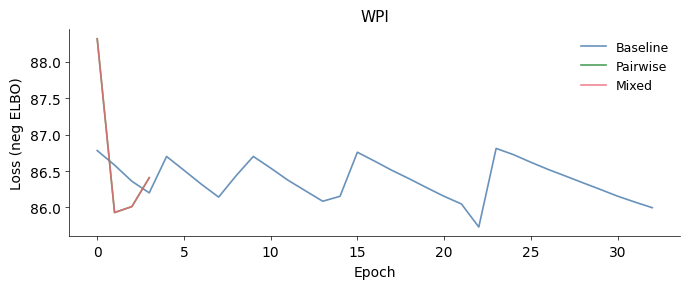

In [15]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='WPI',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [17]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/116 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
  Q1     1.0000    0.0010              False
  Q2     1.0000    0.0010              False
  Q3     0.9077    0.0010              False
  Q4     0.6610    0.0010              False
  Q5     0.4684    0.0010              False
  Q6     0.8450    0.0010              False
  Q7     0.7949    0.0010              False
  Q8     0.7003    0.0010              False
  Q9     0.6002    0.0010              False
 Q10     0.8495    0.0010              False
 Q11     1.0000    0.0010              False
 Q12     0.4558    0.0010              False
 Q13     0.2959    0.0010              False
 Q14     0.8839    0.0010              False
 Q15     0.5593    0.0010              False
 Q16     0.4609    0.0010              False
 Q17     0.5812    0.0010              False
 Q18     0.4866    0.0010              False
 Q19     0.0000    0.0010              False
 Q20     0.2419    0.0010              Fals

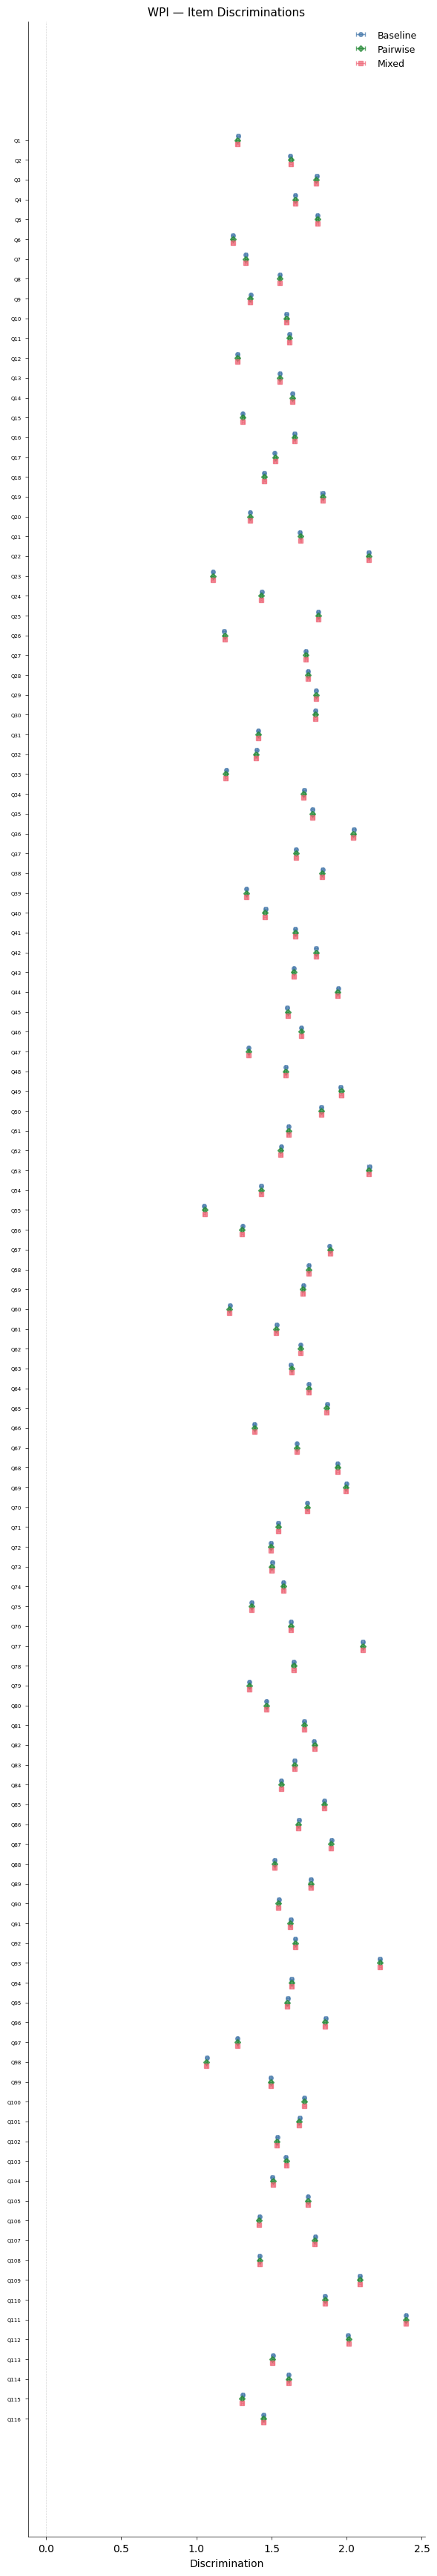

In [18]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed, title='WPI — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('item_discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

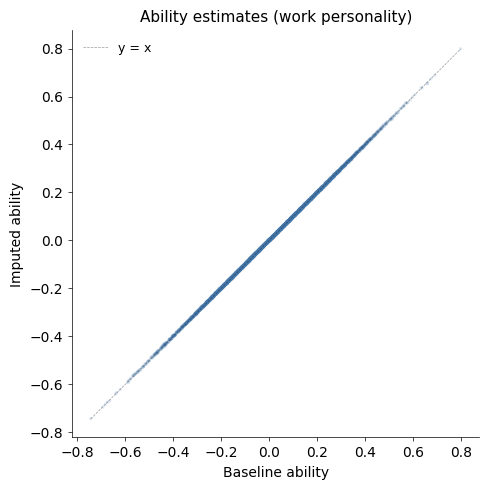

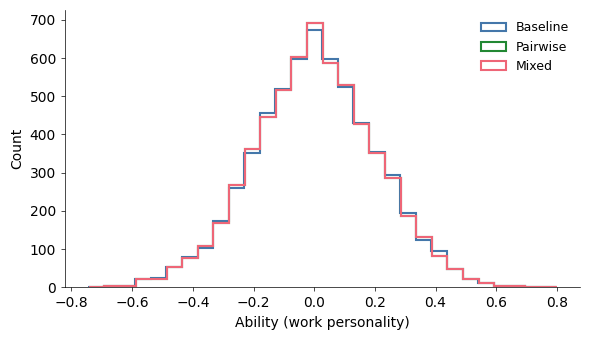

In [19]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='work personality')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='work personality',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

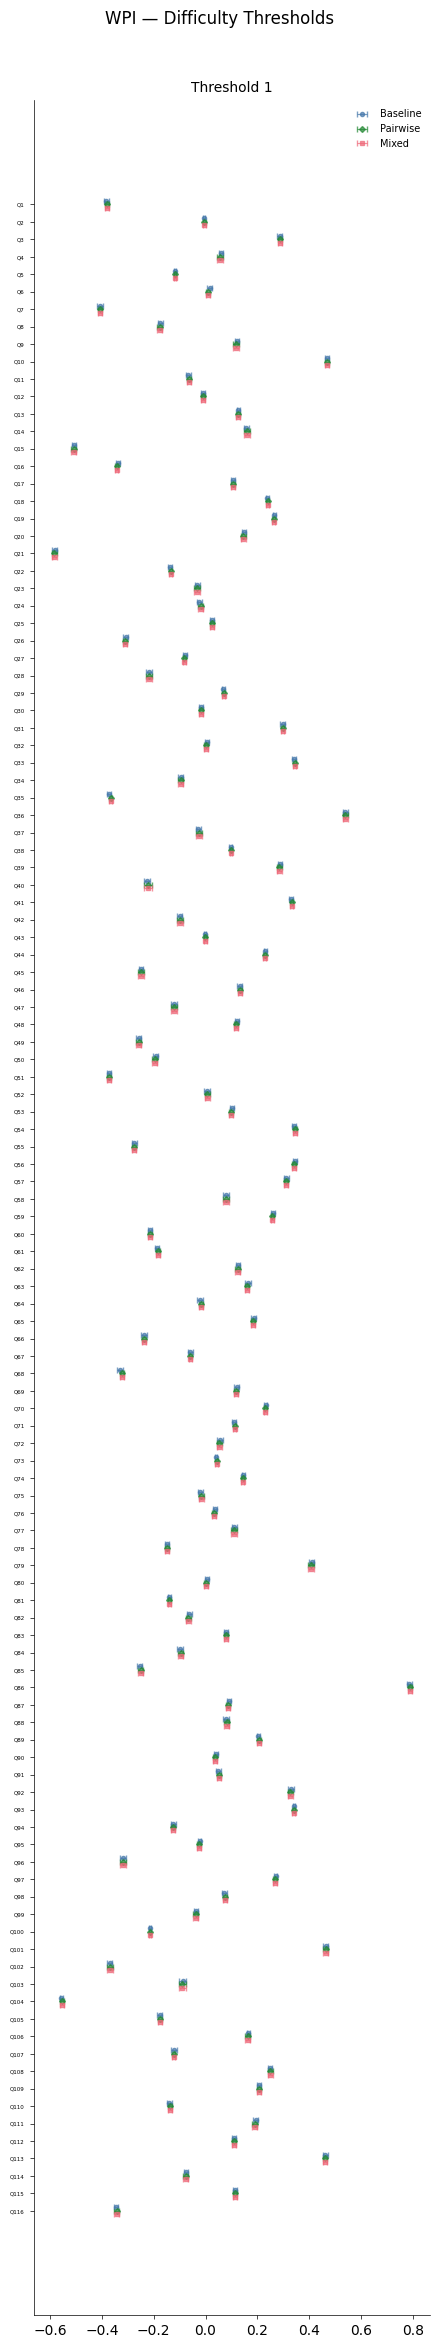

In [20]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed, title='WPI — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('difficulty_thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

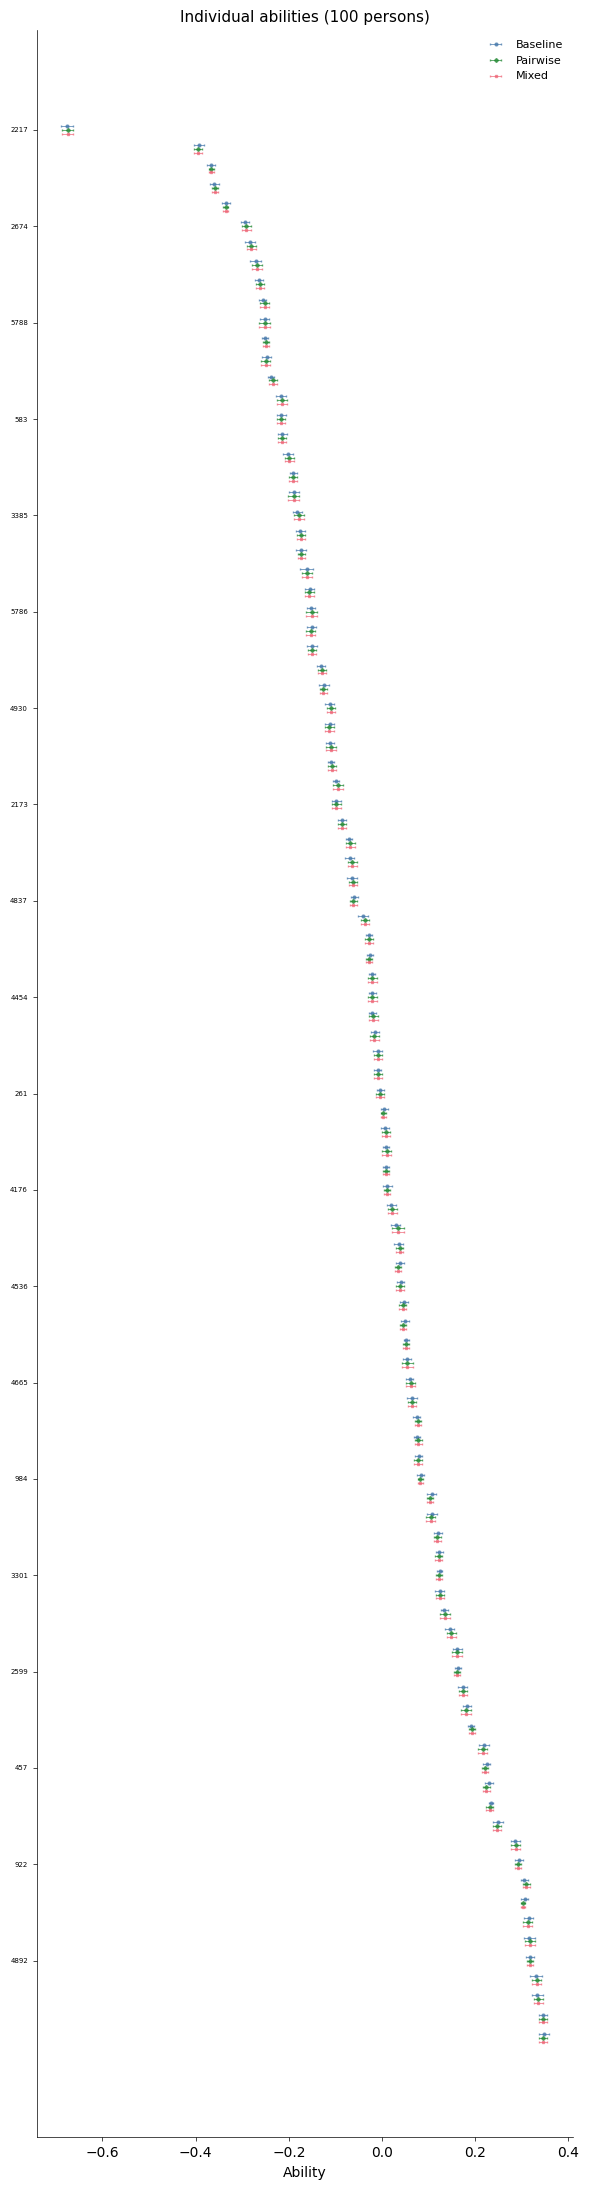

In [21]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

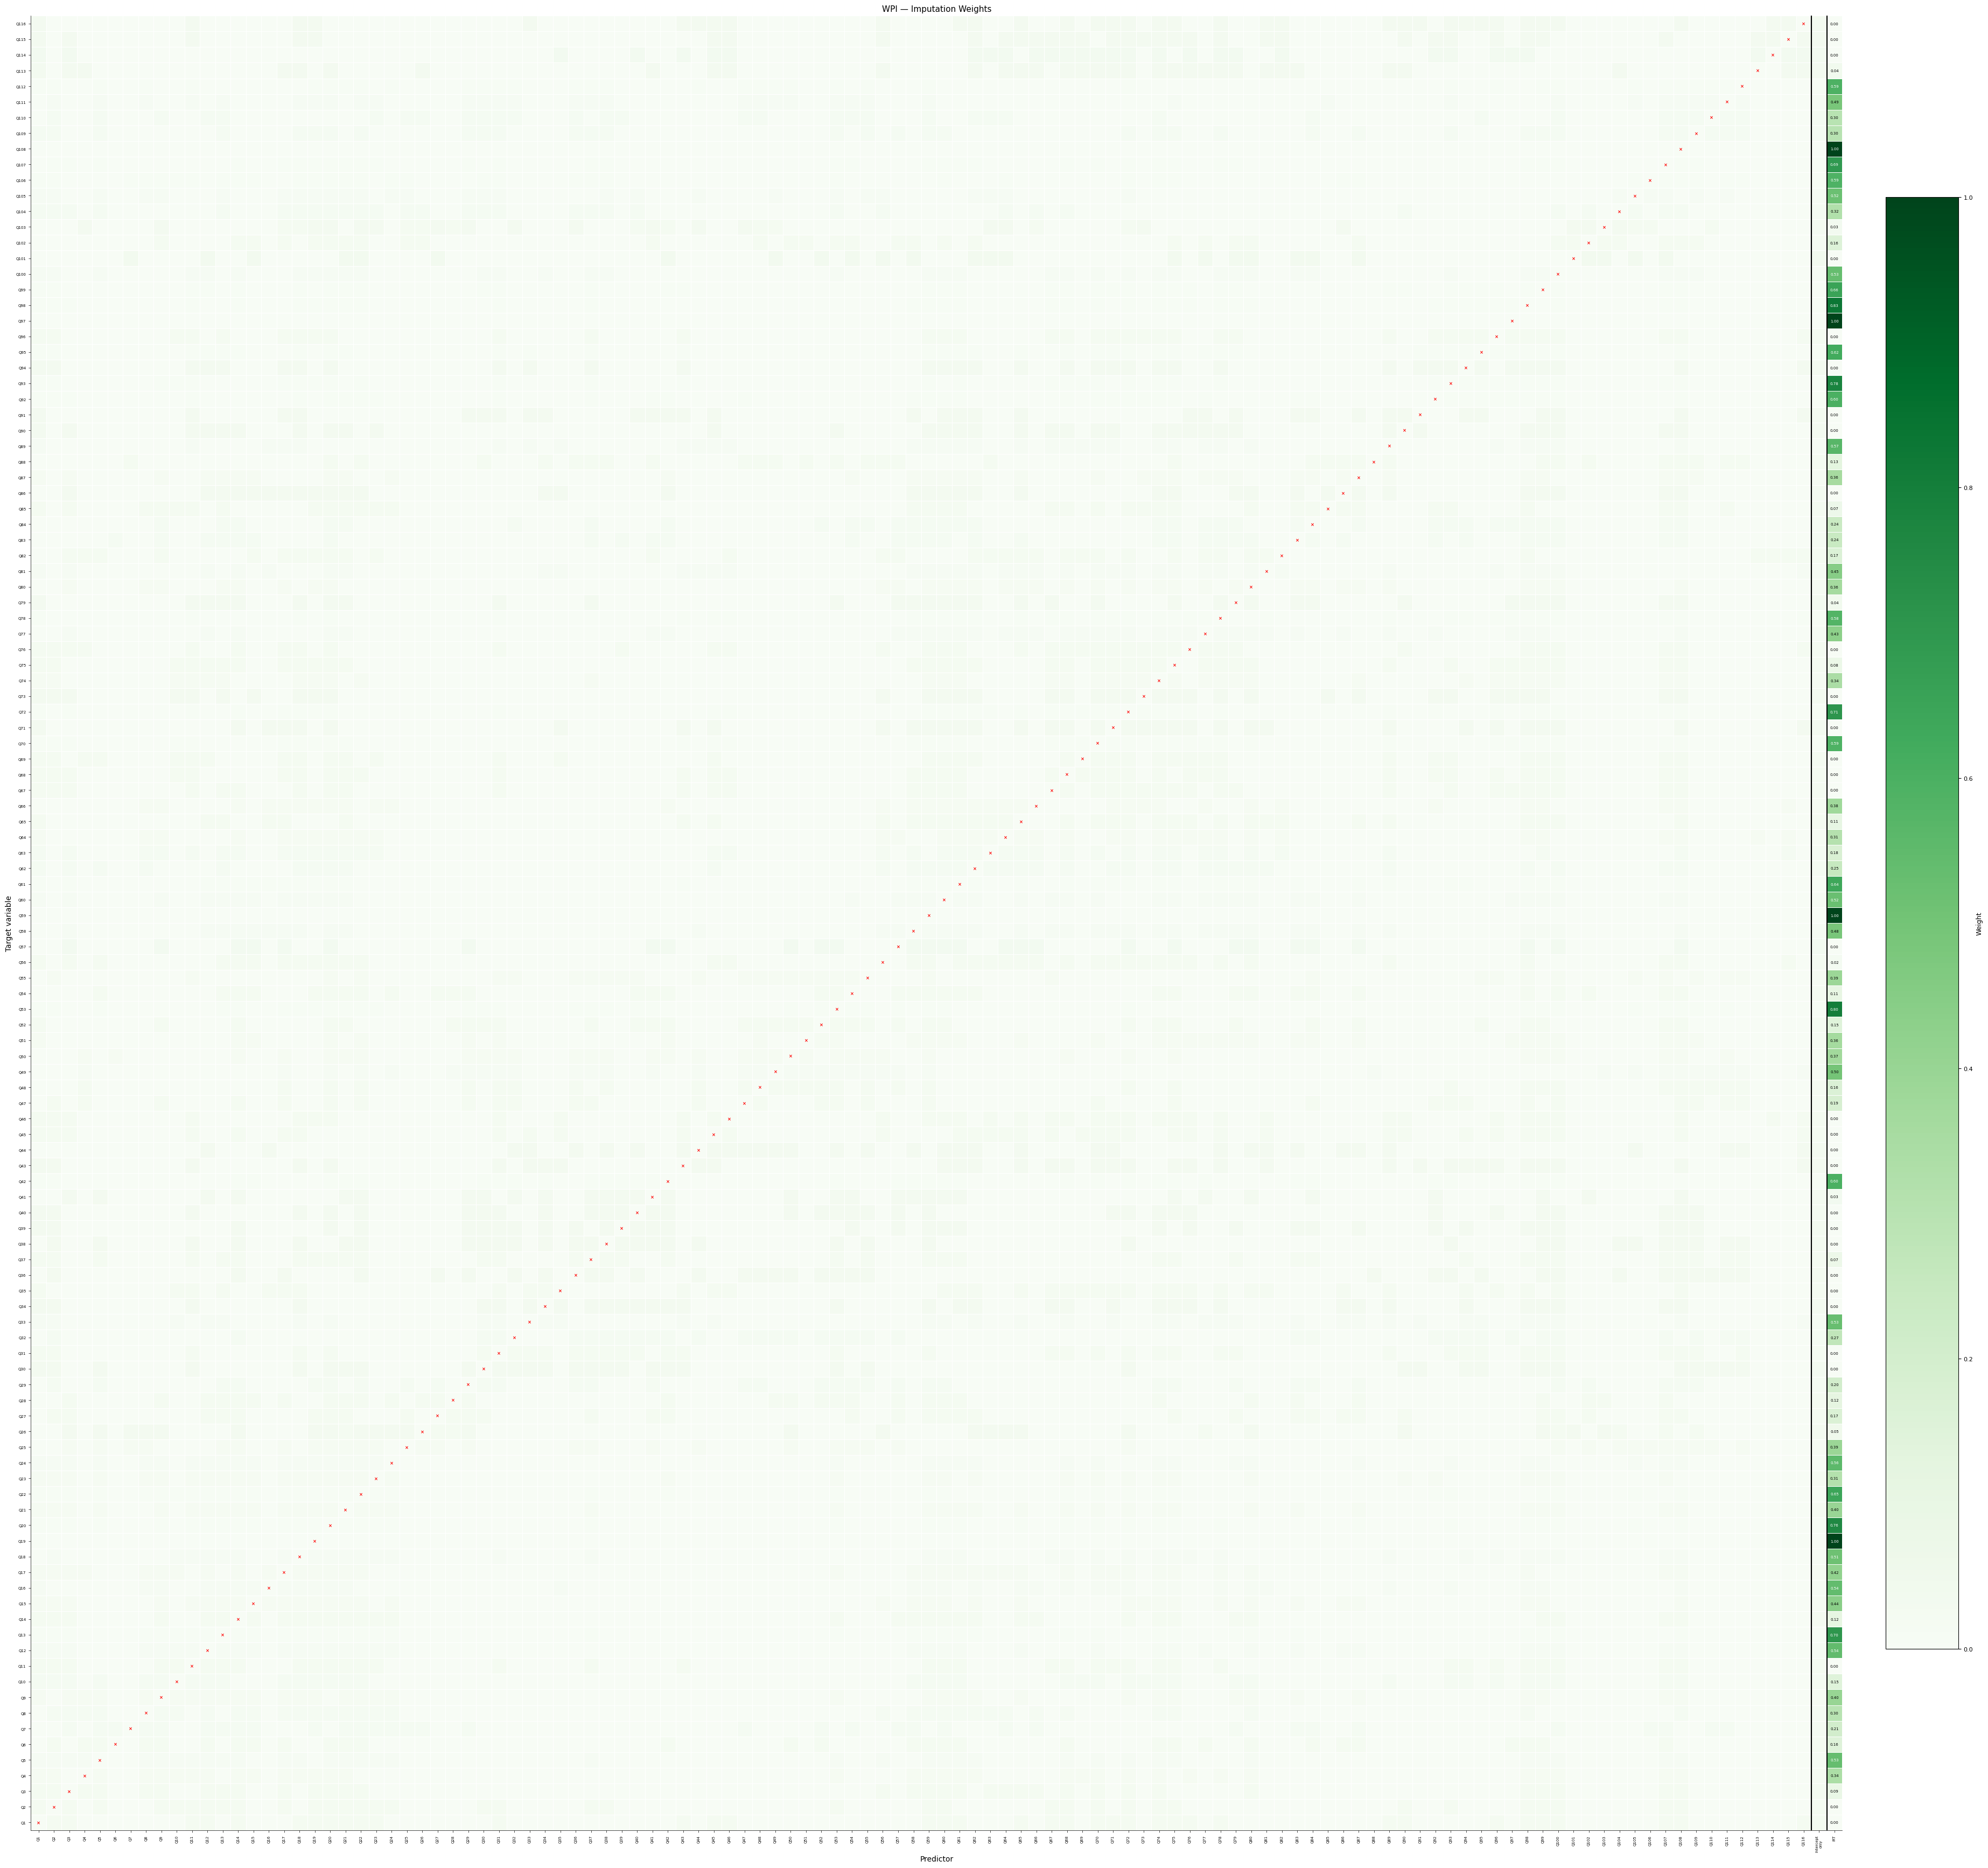

In [22]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='WPI — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

In [23]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("WPI — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))


WPI — Predictive Performance Comparison

   Metric        Baseline        Pairwise           Mixed
     RMSE   0.513 (0.000)   0.513 (0.000)   0.513 (0.000)
   ELPD/n -83.198 (0.101) -83.147 (0.100) -83.147 (0.100)
ELPD/resp  -0.723 (0.001)  -0.723 (0.001)  -0.723 (0.001)
 Spearman          0.0257          0.0267          0.0267


## Summary

This notebook demonstrated fitting a single-scale GRM (equivalent to a 2PL model
for binary items) to the 116-item Woodworth Psychoneurotic Inventory:

1. **Baseline (ignorable missingness)**: Missing responses have their log-likelihood
   zeroed out.
2. **Pairwise-only imputation**: A `PairwiseOrdinalStackingModel` provides imputed
   PMFs for all missing cells (w=1 everywhere, no IRT blending).
3. **Mixed imputation (Pairwise + IRT)**: The pairwise model is blended with the
   baseline IRT model's marginalized predictions via per-item softmax weights over
   ELPD scores: `PMF = w_pw * Pairwise + (1 - w_pw) * IRT_baseline`.
4. **Analytic Rao-Blackwellized imputation**: The GRM analytically marginalizes over
   the blended imputation PMF for missing cells, yielding zero-variance contributions.

Discrimination and ability estimates from all three approaches can be compared to
assess the impact of the missingness-handling strategy.